# 22 featrures according model trained

## 01_data_exploration.ipynb

In [2]:
import os
import polars as pl

batch = os.getcwd()
path = os.path.join(batch, '..', 'data', 'kidney_disease.csv')
path = os.path.normpath(path)
 
df = pl.read_csv(
    path,
    null_values=["?", "", "NA", "N/A", "nan", "NaN"],
    infer_schema_length=10000,
    ignore_errors=True
)

print("Loaded Successfully!")
print("Shape        :", df.shape)
print("Null counts  :")
print(df.null_count())
print(df.head())

Loaded Successfully!
Shape        : (400, 26)
Null counts  :
shape: (1, 26)
┌─────┬─────┬─────┬─────┬───┬───────┬─────┬─────┬────────────────┐
│ id  ┆ age ┆ bp  ┆ sg  ┆ … ┆ appet ┆ pe  ┆ ane ┆ classification │
│ --- ┆ --- ┆ --- ┆ --- ┆   ┆ ---   ┆ --- ┆ --- ┆ ---            │
│ u32 ┆ u32 ┆ u32 ┆ u32 ┆   ┆ u32   ┆ u32 ┆ u32 ┆ u32            │
╞═════╪═════╪═════╪═════╪═══╪═══════╪═════╪═════╪════════════════╡
│ 0   ┆ 9   ┆ 12  ┆ 47  ┆ … ┆ 1     ┆ 1   ┆ 1   ┆ 0              │
└─────┴─────┴─────┴─────┴───┴───────┴─────┴─────┴────────────────┘
shape: (5, 26)
┌─────┬──────┬──────┬───────┬───┬───────┬─────┬─────┬────────────────┐
│ id  ┆ age  ┆ bp   ┆ sg    ┆ … ┆ appet ┆ pe  ┆ ane ┆ classification │
│ --- ┆ ---  ┆ ---  ┆ ---   ┆   ┆ ---   ┆ --- ┆ --- ┆ ---            │
│ i64 ┆ f64  ┆ f64  ┆ f64   ┆   ┆ str   ┆ str ┆ str ┆ str            │
╞═════╪══════╪══════╪═══════╪═══╪═══════╪═════╪═════╪════════════════╡
│ 0   ┆ 48.0 ┆ 80.0 ┆ 1.02  ┆ … ┆ good  ┆ no  ┆ no  ┆ ckd            │
│ 1   ┆ 7.0  ┆

## 02_data_cleaning.ipynb

In [3]:
df.null_count()

id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,9,12,47,46,49,152,65,4,4,44,19,17,87,88,52,70,105,130,2,2,2,1,1,1,0


In [4]:
def fill_numeric_with_median(df: pl.DataFrame) -> pl.DataFrame:
    import polars.selectors as cs
    return df.with_columns(
        cs.numeric().fill_null(cs.numeric().median())
    )

df = fill_numeric_with_median(df)

In [5]:
def fill_string_with_mode(df: pl.DataFrame) -> pl.DataFrame:
    import polars.selectors as cs
    return df.with_columns(
        cs.string().fill_null(cs.string().mode())
    )

df = fill_string_with_mode(df)

In [6]:
import polars as pl

num_cols = ["age", "bp", "sg", "al", "su", "bgr", "bu", "sc", 
            "sod", "pot", "hemo", "pcv", "wc", "rc"]

df = df.with_columns([
    pl.col(col)
      .cast(pl.Utf8)                  # ensure string first
      .str.strip_chars()              # remove whitespace/tabs
      .str.replace(r"[^\d.]", "")    # remove non-numeric chars like "?"
      .replace("", None)             # empty string → null
      .cast(pl.Float64)              # now safely cast to numeric
    for col in num_cols
])

# Now median fill works ✅
df = df.with_columns([
    pl.col(col).fill_null(pl.col(col).median())
    for col in num_cols
])

In [7]:
df = df.drop('id')

In [8]:
df.null_count()

age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 03_eda.ipynb

In [9]:
import plotly.express as px

fig = px.box(
    data_frame=df,
    x="age",
    y="bp",
    color="classification",
    boxmode="group",
    notched=True,
    points="all",
    hover_name="classification",
    hover_data={
        "age": True,
        "al": True,
        "bp": True,
    },
    # facet_col="classification",  
    orientation="v",
    title="Kidney Disease - Age vs Blood Pressure",
    labels={
        "age": "Age",
        "bp": "Blood Pressure",
        "classification": "CKD Status",
    },
    category_orders={
        "classification": ["ckd", "notckd"]  
    },
    color_discrete_map={
        "ckd":    "#EF553B",   
        "notckd": "#636EFA",
    },
    template="plotly_white",
    width=950,
    height=600,
)

fig.update_traces(
    jitter=0.3,
    pointpos=-1.5,
    opacity=0.8,
)

fig.show()

In [10]:
import plotly.express as px

# Box plot — shows outlier dots automatically
fig = px.box(df, y="bp", points="outliers", title="BP Outliers")
fig.show()

# For all numeric columns
import polars.selectors as cs
num_cols = df.select(cs.numeric()).columns

fig = px.box(df.to_pandas()[num_cols], title="All Numeric Outliers")
fig.show()

In [11]:
import polars as pl
import polars.selectors as cs

def remove_outliers_zscore(df: pl.DataFrame, col: str, threshold=3) -> pl.DataFrame:
    mean = df[col].mean()
    std  = df[col].std()
    return df.filter(
        ((pl.col(col) - mean) / std).abs() < threshold
    )

num_cols = df.select(cs.numeric()).columns

df_clean = df.clone()
for col in num_cols:
    df_clean = remove_outliers_zscore(df_clean, col=col)

In [12]:
num_cols = df_clean.select(cs.numeric()).columns
fig = px.box(df_clean.to_pandas()[num_cols], title="All Numeric Outliers")
fig.show()

## 04_feature_engineering.ipynb

In [13]:
cat_col = df_clean.select(cs.string()).columns
cat_col

['rbc',
 'pc',
 'pcc',
 'ba',
 'htn',
 'dm',
 'cad',
 'appet',
 'pe',
 'ane',
 'classification']

In [14]:
import polars.selectors as cs

cat_cols = df_clean.select(cs.string()).columns

for col in cat_cols:
    print(f"\n── {col} ──")
    print(df[col].value_counts(sort=True))


── rbc ──
shape: (2, 2)
┌──────────┬───────┐
│ rbc      ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ normal   ┆ 353   │
│ abnormal ┆ 47    │
└──────────┴───────┘

── pc ──
shape: (2, 2)
┌──────────┬───────┐
│ pc       ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ normal   ┆ 324   │
│ abnormal ┆ 76    │
└──────────┴───────┘

── pcc ──
shape: (2, 2)
┌────────────┬───────┐
│ pcc        ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ notpresent ┆ 358   │
│ present    ┆ 42    │
└────────────┴───────┘

── ba ──
shape: (2, 2)
┌────────────┬───────┐
│ ba         ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ notpresent ┆ 378   │
│ present    ┆ 22    │
└────────────┴───────┘

── htn ──
shape: (2, 2)
┌─────┬───────┐
│ htn ┆ count │
│ --- ┆ ---   │
│ str ┆ u32   │
╞═════╪═══════╡
│ no  ┆ 253   │
│ yes ┆ 147   │
└─────┴───────┘

── dm ──
shape: (5, 2)
┌──────┬───────┐
│ dm

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV


In [16]:
X, y = df_clean.drop('classification'), df_clean['classification']

In [17]:
num_col = X.select(cs.numeric()).columns
cat_col = X.select(cs.string()).columns


len(cat_col), len(num_col)

(10, 14)

In [18]:
X.head(), y.head()

(shape: (5, 24)
 ┌──────┬───────┬───────┬─────┬───┬─────┬───────┬─────┬─────┐
 │ age  ┆ bp    ┆ sg    ┆ al  ┆ … ┆ cad ┆ appet ┆ pe  ┆ ane │
 │ ---  ┆ ---   ┆ ---   ┆ --- ┆   ┆ --- ┆ ---   ┆ --- ┆ --- │
 │ f64  ┆ f64   ┆ f64   ┆ f64 ┆   ┆ str ┆ str   ┆ str ┆ str │
 ╞══════╪═══════╪═══════╪═════╪═══╪═════╪═══════╪═════╪═════╡
 │ 48.0 ┆ 80.0  ┆ 1.02  ┆ 1.0 ┆ … ┆ no  ┆ good  ┆ no  ┆ no  │
 │ 7.0  ┆ 50.0  ┆ 1.02  ┆ 4.0 ┆ … ┆ no  ┆ good  ┆ no  ┆ no  │
 │ 51.0 ┆ 80.0  ┆ 1.01  ┆ 2.0 ┆ … ┆ no  ┆ good  ┆ no  ┆ no  │
 │ 60.0 ┆ 90.0  ┆ 1.015 ┆ 3.0 ┆ … ┆ no  ┆ good  ┆ yes ┆ no  │
 │ 52.0 ┆ 100.0 ┆ 1.015 ┆ 3.0 ┆ … ┆ no  ┆ good  ┆ no  ┆ yes │
 └──────┴───────┴───────┴─────┴───┴─────┴───────┴─────┴─────┘,
 shape: (10,)
 Series: 'classification' [str]
 [
 	"ckd"
 	"ckd"
 	"ckd"
 	"ckd"
 	"ckd"
 	"ckd"
 	"ckd"
 	"ckd"
 	"ckd"
 	"ckd"
 ])

In [19]:
encode = OrdinalEncoder(categories=[
    ['normal', 'abnormal'],
    ['normal', 'abnormal'],
    ['present', 'notpresent'],
    ['present', 'notpresent'],
    ['no', 'yes'],
    ['no', 'yes'],
    ['no', 'yes'],
    ['good', 'poor'],
    ['no', 'yes'],
    ['no', 'yes'],  
],handle_unknown="use_encoded_value", unknown_value=-1)

scaler = MinMaxScaler()

In [20]:
transform = ColumnTransformer(
    transformers=[
        ('ordinal', encode, cat_col),
        ('scaler',scaler , num_col),
    ]
)

In [21]:
# Clean all string columns in Polars
X = X.with_columns(
    pl.col(cat_col).str.strip_chars()
)

In [22]:
import pandas as pd
x_pd = X.to_pandas()
# result = transform.fit_transform(x_pd
#                                  )
# print(result.shape)   # should be (rows, expected_cols)
# print(result[:5])     # first 5 rows


In [23]:
from sklearn.preprocessing import LabelEncoder

# Strip directly on the Series
y = y.str.strip_chars()

# Encode
y_encoded = LabelEncoder().fit_transform(y)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(x_pd, y_encoded, test_size=0.2, random_state=42)


In [25]:
len(X_train.columns)

24

In [26]:
X_train_scaled = transform.fit_transform(X_train)
X_test_scaled = transform.transform(X_test)

In [27]:
X_train_scaled.shape

(272, 24)

## 05_model_building.ipynb

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
import numpy as np


In [29]:
dt_params = {
    "criterion":        ["gini", "entropy", "log_loss"],
    "splitter":         ["best", "random"],
    "max_depth":        [None, 3, 5, 10, 20],
    "min_samples_split":[2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [None, "sqrt", "log2"],
    "max_leaf_nodes":   [None, 10, 20, 50],
    "class_weight":     [None, "balanced"],
}

mnb_params = {
    "alpha":     [0.0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    "fit_prior": [True, False],
}

gnb_params = {
    "var_smoothing": np.logspace(-11, -5, 30),   # 30 log-spaced values
}

In [30]:
dt_mode = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=dt_params,
    n_jobs=-1,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42

)

dt_mode.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 3, ...], 'max_features': [None, 'sqrt', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [31]:
dt_mode.score(X_test_scaled, y_test)

0.9852941176470589

In [32]:
# mnb_mode = RandomizedSearchCV(
#     MultinomialNB(),
#     param_distributions=mnb_params,
#     n_jobs=-1,
#     n_iter=10,
#     cv=5,
#     scoring='accuracy',
#     random_state=42

# )

# mnb_mode.fit(X_train_scaled, y_train)

In [33]:
gnb_mode = RandomizedSearchCV(
    GaussianNB(),
    param_distributions=gnb_params,
    n_jobs=-1,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42

)

gnb_mode.fit(X_train_scaled, y_train)

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning:

The total space of parameters 30 is smaller than n_iter=50. Running 30 iterations. For exhaustive searches, use GridSearchCV.



,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'var_smoothing': array([1.0000...00000000e-05])}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose ver

In [34]:
gnb_mode.score(X_test_scaled, y_test)

0.9852941176470589

In [35]:
print(dt_mode.best_params_)
print(gnb_mode.best_params_)

{'splitter': 'random', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': 20, 'criterion': 'log_loss', 'class_weight': None}
{'var_smoothing': np.float64(1e-11)}


In [36]:
model_dt = dt_mode.best_estimator_
y_pred = model_dt.predict(X_test_scaled)

In [37]:
testing = pl.DataFrame({'true':y_test[:10], 'pred': y_pred[:10]})
print(testing)

shape: (10, 2)
┌──────┬──────┐
│ true ┆ pred │
│ ---  ┆ ---  │
│ i64  ┆ i64  │
╞══════╪══════╡
│ 1    ┆ 1    │
│ 0    ┆ 0    │
│ 0    ┆ 0    │
│ 0    ┆ 0    │
│ 0    ┆ 0    │
│ 1    ┆ 1    │
│ 0    ┆ 0    │
│ 1    ┆ 1    │
│ 1    ┆ 1    │
│ 0    ┆ 0    │
└──────┴──────┘


In [38]:
model_gnb = gnb_mode.best_estimator_
y_pred_1 = model_gnb.predict(X_test_scaled)

In [39]:
testing_1 = pl.DataFrame({'true':y_test[:10], 'pred': y_pred[:10]})
print(testing_1)

shape: (10, 2)
┌──────┬──────┐
│ true ┆ pred │
│ ---  ┆ ---  │
│ i64  ┆ i64  │
╞══════╪══════╡
│ 1    ┆ 1    │
│ 0    ┆ 0    │
│ 0    ┆ 0    │
│ 0    ┆ 0    │
│ 0    ┆ 0    │
│ 1    ┆ 1    │
│ 0    ┆ 0    │
│ 1    ┆ 1    │
│ 1    ┆ 1    │
│ 0    ┆ 0    │
└──────┴──────┘


## model comparison for matrix methods

In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
import plotly.graph_objects as go

dt_confusion_matrix = confusion_matrix(y_test, y_pred)
gnb_confusion_matrix = confusion_matrix(y_test, y_pred_1)
dt_accuracy = accuracy_score(y_test, y_pred)
gnb_accuracy = accuracy_score(y_test, y_pred_1)
dt_f1Score = f1_score(y_test, y_pred)
gnb_f1Score= f1_score(y_test, y_pred_1)
dt_recall = recall_score(y_test, y_pred)
gnb_recall = recall_score(y_test, y_pred_1)
dt_precison = precision_score(y_test, y_pred)
gnb_precison = precision_score(y_test, y_pred_1)


metrics_df = pl.DataFrame({
    "model":     ["Decision Tree", "Gaussian NB"],
    "accuracy":  [dt_accuracy,     gnb_accuracy],
    "f1_score":  [dt_f1Score,      gnb_f1Score],
    "recall":    [dt_recall,       gnb_recall],
    "precision": [dt_precison,     gnb_precison],
})




In [41]:
import os
import plotly.io as pio

# --- Grouped Bar Chart ---
metrics = ["accuracy", "f1_score", "recall", "precision"]
colors  = ["#4C9BE8", "#E8834C"]

fig = go.Figure()

for i, row in enumerate(metrics_df.iter_rows(named=True)):
    fig.add_trace(go.Bar(
        name=row["model"],
        x=metrics,
        y=[row["accuracy"], row["f1_score"], row["recall"], row["precision"]],
        marker_color=colors[i],
        text=[f"{v:.2f}" for v in [row["accuracy"], row["f1_score"], row["recall"], row["precision"]]],
        textposition="outside",
    ))

fig.update_layout(
    title="Model Metrics Comparison",
    barmode="group",
    xaxis_title="Metric",
    yaxis_title="Score",
    yaxis=dict(range=[0, 1.15]),
    legend_title="Model",
    height=500,
    width=750,
    template="plotly_white",
)

# --- Save Image ---
batch = os.getcwd()
path  = os.path.join(batch, '..', 'outputs', 'figures', 'comparison_table.png')   

os.makedirs(os.path.dirname(path), exist_ok=True)    

fig.write_image(path)    
fig.show()

In [42]:
import plotly.figure_factory as ff
import plotly.graph_objects as go

import numpy as np

# --- After predictions ---
 
labels =  ["ckd", "notckd"]

cm = confusion_matrix(y_test, y_pred)

# --- Plotly Heatmap ---
fig1 = ff.create_annotated_heatmap(
    z=cm,
    x=list(labels),           # predicted (columns)
    y=list(labels),            # actual (rows)
    annotation_text=cm,        # show numbers in cells
    colorscale="Blues",
    showscale=True,
)

# --- Labels ---
fig1.update_layout(
    title="Confusion Matrix",
    xaxis=dict(title="Predicted Label", side="bottom"),
    yaxis=dict(title="Actual Label", autorange="reversed"),  # top-to-bottom
    width=500,
    height=450,
)

fig1.show()

In [43]:
labels =  ["ckd", "notckd"]

cm = confusion_matrix(y_test, y_pred_1)

# --- Plotly Heatmap ---
fig = ff.create_annotated_heatmap(
    z=cm,
    x=list(labels),           # predicted (columns)
    y=list(labels),            # actual (rows)
    annotation_text=cm,        # show numbers in cells
    colorscale="Blues",
    showscale=True,
)

# --- Labels ---
fig.update_layout(
    title="Confusion Matrix",
    xaxis=dict(title="Predicted Label", side="bottom"),
    yaxis=dict(title="Actual Label", autorange="reversed"),  # top-to-bottom
    width=500,
    height=450,
)

fig.show()

## save martix 

In [44]:
batch = os.getcwd()
path  = os.path.join(batch, '..', 'outputs', 'figures', 'confusion_gnb.png')
path1  = os.path.join(batch, '..', 'outputs', 'figures', 'confusion_dt.png')

os.makedirs(os.path.dirname(path), exist_ok=True)    

fig.write_image(path)  
fig1.write_image(path1)

## save column transformer

In [45]:
import joblib as jl
batch = os.getcwd()
path  = os.path.join(batch,'..' ,'outputs','models', 'encoding.pkl')
os.makedirs(os.path.dirname(path), exist_ok=True)
jl.dump(transform, path)


['c:\\Users\\sumit\\OneDrive\\Desktop\\project work\\kidney-failure-detection\\notebook\\..\\outputs\\models\\encoding.pkl']

## model make for good parms fully trained

In [46]:
model_dt = DecisionTreeClassifier(splitter='best', min_samples_split=10, min_samples_leaf = 10, max_leaf_nodes = 20, max_features = None, max_depth= 5, criterion='gini', class_weight = None)


model_gnb = GaussianNB(var_smoothing = np.float64(1e-11))

In [47]:
model_dt.fit(X_train_scaled, y_train)
model_gnb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",np.float64(1e-11)


In [48]:
model_gnb.score(X_test_scaled, y_test),model_dt.score(X_test_scaled, y_test)


(0.9852941176470589, 0.9558823529411765)

In [49]:
batch = os.getcwd()
path_dt  = os.path.join(batch,'..' ,'outputs','models', 'model_dt.pkl')
path_gnb  = os.path.join(batch,'..' ,'outputs','models', 'model_gnb.pkl')
os.makedirs(os.path.dirname(path), exist_ok=True)

jl.dump(model_dt,path_dt)
jl.dump(model_gnb, path_gnb)

['c:\\Users\\sumit\\OneDrive\\Desktop\\project work\\kidney-failure-detection\\notebook\\..\\outputs\\models\\model_gnb.pkl']

# 10 features according model trained

## 10 features selection 

In [50]:
x_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     340 non-null    float64
 1   bp      340 non-null    float64
 2   sg      340 non-null    float64
 3   al      340 non-null    float64
 4   su      340 non-null    float64
 5   rbc     340 non-null    object 
 6   pc      340 non-null    object 
 7   pcc     340 non-null    object 
 8   ba      340 non-null    object 
 9   bgr     340 non-null    float64
 10  bu      340 non-null    float64
 11  sc      340 non-null    float64
 12  sod     340 non-null    float64
 13  pot     340 non-null    float64
 14  hemo    340 non-null    float64
 15  pcv     340 non-null    float64
 16  wc      340 non-null    float64
 17  rc      340 non-null    float64
 18  htn     340 non-null    object 
 19  dm      340 non-null    object 
 20  cad     340 non-null    object 
 21  appet   340 non-null    object 
 22  pe

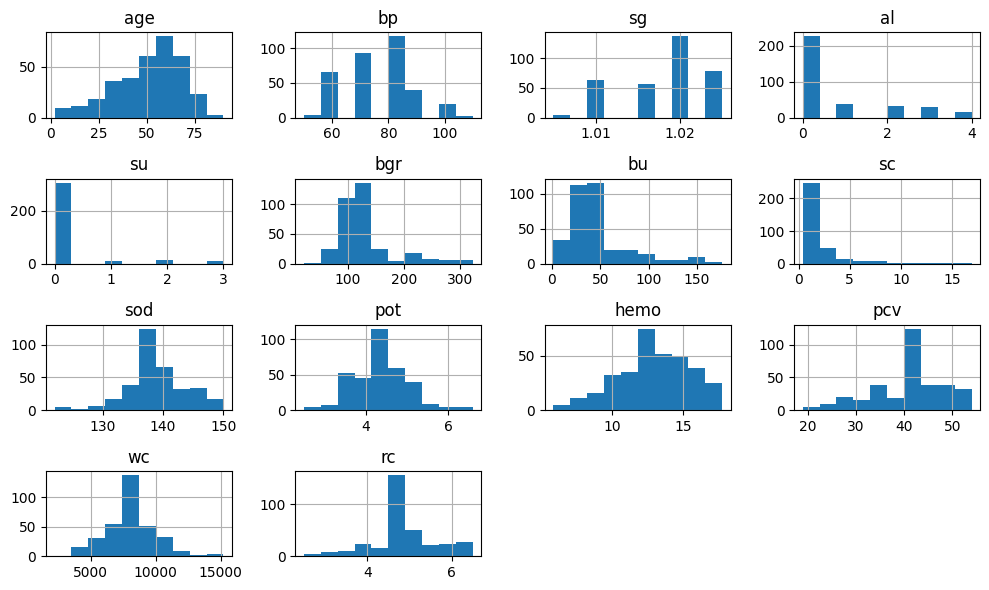

In [51]:
import matplotlib.pyplot as plt
x_pd.hist(figsize=(10, 6))
plt.tight_layout()


In [52]:
X_10 = x_pd[['age', 'bp','sg', 'al', 'su', 'bgr', 'bu', 'sc','sod', 'pot',  'hemo', 'pcv', 'wc', 'rc']]

In [53]:
X_pl = pl.from_pandas(X_10)
for col in X_pl.columns:
    print(X_pl[col])

X_pl['age'].max()

shape: (340,)
Series: 'age' [f64]
[
	48.0
	7.0
	51.0
	60.0
	52.0
	…
	55.0
	42.0
	12.0
	17.0
	58.0
]
shape: (340,)
Series: 'bp' [f64]
[
	80.0
	50.0
	80.0
	90.0
	100.0
	…
	80.0
	70.0
	80.0
	60.0
	80.0
]
shape: (340,)
Series: 'sg' [f64]
[
	1.02
	1.02
	1.01
	1.015
	1.015
	…
	1.02
	1.025
	1.02
	1.025
	1.025
]
shape: (340,)
Series: 'al' [f64]
[
	1.0
	4.0
	2.0
	3.0
	3.0
	…
	0.0
	0.0
	0.0
	0.0
	0.0
]
shape: (340,)
Series: 'su' [f64]
[
	0.0
	0.0
	0.0
	0.0
	0.0
	…
	0.0
	0.0
	0.0
	0.0
	0.0
]
shape: (340,)
Series: 'bgr' [f64]
[
	121.0
	121.0
	106.0
	74.0
	138.0
	…
	140.0
	75.0
	100.0
	114.0
	131.0
]
shape: (340,)
Series: 'bu' [f64]
[
	36.0
	18.0
	26.0
	25.0
	60.0
	…
	49.0
	31.0
	26.0
	50.0
	18.0
]
shape: (340,)
Series: 'sc' [f64]
[
	1.2
	0.8
	1.4
	1.1
	1.9
	…
	0.5
	1.2
	0.6
	1.0
	1.1
]
shape: (340,)
Series: 'sod' [f64]
[
	138.0
	138.0
	138.0
	142.0
	138.0
	…
	150.0
	141.0
	137.0
	135.0
	141.0
]
shape: (340,)
Series: 'pot' [f64]
[
	4.4
	4.4
	4.4
	3.2
	4.4
	…
	4.9
	3.5
	4.4
	4.9
	3.5
]
shape: (340,)

90.0

In [54]:
X_pl = (
    X_pl
    .with_columns([
        (pl.col("bp")  * pl.col("sg")).alias("bp_sg"),
        (pl.col("bgr") * pl.col("bu")).alias("bgr_bu"),
        (pl.col("sc")  * pl.col("sod")).alias("sc_sod"),
        (pl.col("pot") * pl.col("hemo")).alias("pot_hemo"),
        (pl.col("wc")  * pl.col("rc")).alias("wc_rc"),
    ])
    .drop(["bp", "sg", "bgr", "bu", "sc", "sod", "pot", "hemo", "wc", "rc"])
)

len(X_pl.columns)

9

In [55]:
X_pl.describe()

statistic,age,al,su,pcv,bp_sg,bgr_bu,sc_sod,pot_hemo,wc_rc
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",340.0,340.0,340.0,340.0,340.0,340.0,340.0,340.0,340.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",50.626471,0.741176,0.188235,40.423529,77.0725,6494.737353,286.349706,56.416588,39170.323529
"""std""",17.256999,1.208651,0.623892,7.357097,11.687627,5876.873556,326.792638,13.178894,10211.731969
"""min""",2.0,0.0,0.0,19.0,50.5,33.0,58.8,22.62,10560.0
"""25%""",41.0,0.0,0.0,36.0,70.7,2952.0,124.2,48.07,34300.0
"""50%""",54.0,0.0,0.0,40.0,80.8,4845.0,170.4,55.66,38400.0
"""75%""",64.0,1.0,0.0,45.0,82.0,7884.0,303.6,65.8,43200.0
"""max""",90.0,4.0,3.0,54.0,111.65,38544.0,2332.2,89.0,71520.0


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

In [57]:

y = y.str.strip_chars()

sclaed_10 = MinMaxScaler()

y_encoded_10 = LabelEncoder().fit_transform(y)

In [58]:
X_pl = X_pl.to_numpy()


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X_pl, y_encoded_10, test_size=0.2, random_state=42)

In [60]:
X_train_10 = sclaed_10.fit_transform(X_train)
X_test_10 = sclaed_10.transform(X_test)


In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
import numpy as np


In [62]:
dt_params = {
    "criterion":        ["gini", "entropy", "log_loss"],
    "splitter":         ["best", "random"],
    "max_depth":        [None, 3, 5, 10, 20],
    "min_samples_split":[2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [None, "sqrt", "log2"],
    "max_leaf_nodes":   [None, 10, 20, 50],
    "class_weight":     [None, "balanced"],
}

mnb_params = {
    "alpha":     [0.0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    "fit_prior": [True, False],
}

gnb_params = {
    "var_smoothing": np.logspace(-11, -5, 30),   # 30 log-spaced values
}

In [63]:
dt_mode_10 = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=dt_params,
    n_jobs=-1,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42

)

dt_mode_10.fit(X_train_10, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 3, ...], 'max_features': [None, 'sqrt', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [64]:
dt_mode_10.score(X_test_10, y_test)

0.9852941176470589

In [65]:
gnb_mode_10 = RandomizedSearchCV(
    GaussianNB(),
    param_distributions=gnb_params,
    n_jobs=-1,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42

)

gnb_mode_10.fit(X_train_10, y_train)

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning:

The total space of parameters 30 is smaller than n_iter=50. Running 30 iterations. For exhaustive searches, use GridSearchCV.



,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'var_smoothing': array([1.0000...00000000e-05])}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose ver

In [66]:
gnb_mode_10.score(X_test_10, y_test)

0.9411764705882353

In [67]:
model_dt_10 = dt_mode_10.best_estimator_
y_pred_10_dt = model_dt_10.predict(X_test_10)

In [68]:
print(model_dt_10)

DecisionTreeClassifier(class_weight='balanced', criterion='log_loss',
                       max_depth=20, max_features='sqrt', min_samples_leaf=5,
                       min_samples_split=10)


In [69]:
model_gnb_10 = gnb_mode_10.best_estimator_
y_pred_10 = model_gnb_10.predict(X_test_10)

In [70]:
print(model_gnb_10)

GaussianNB(var_smoothing=np.float64(2.2122162910704503e-07))


In [71]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
import plotly.graph_objects as go

dt_confusion_matrix = confusion_matrix(y_test, y_pred_10_dt)
gnb_confusion_matrix = confusion_matrix(y_test, y_pred_10)
dt_accuracy = accuracy_score(y_test, y_pred_10_dt)
gnb_accuracy = accuracy_score(y_test, y_pred_10)
dt_f1Score = f1_score(y_test, y_pred_10_dt)
gnb_f1Score= f1_score(y_test, y_pred_10)
dt_recall = recall_score(y_test, y_pred_10_dt)
gnb_recall = recall_score(y_test, y_pred_10)
dt_precison = precision_score(y_test, y_pred_10_dt)
gnb_precison = precision_score(y_test, y_pred_10)


metrics_df_10 = pl.DataFrame({
    "model":     ["Decision Tree", "Gaussian NB"],
    "accuracy":  [dt_accuracy,     gnb_accuracy],
    "f1_score":  [dt_f1Score,      gnb_f1Score],
    "recall":    [dt_recall,       gnb_recall],
    "precision": [dt_precison,     gnb_precison],
})




In [72]:
import os
import plotly.io as pio

# --- Grouped Bar Chart ---
metrics = ["accuracy", "f1_score", "recall", "precision"]
colors  = ["#4C9BE8", "#E8834C"]

fig = go.Figure()

for i, row in enumerate(metrics_df_10.iter_rows(named=True)):
    fig.add_trace(go.Bar(
        name=row["model"],
        x=metrics,
        y=[row["accuracy"], row["f1_score"], row["recall"], row["precision"]],
        marker_color=colors[i],
        text=[f"{v:.2f}" for v in [row["accuracy"], row["f1_score"], row["recall"], row["precision"]]],
        textposition="outside",
    ))

fig.update_layout(
    title="Model Metrics Comparison",
    barmode="group",
    xaxis_title="Metric",
    yaxis_title="Score",
    yaxis=dict(range=[0, 1.15]),
    legend_title="Model",
    height=500,
    width=750,
    template="plotly_white",
)

# --- Save Image ---
batch = os.getcwd()
path  = os.path.join(batch, '..', 'outputs', 'figures_10', 'comparison_table.png')   

os.makedirs(os.path.dirname(path), exist_ok=True)    

fig.write_image(path)    
fig.show()

In [73]:
 
fig = ff.create_annotated_heatmap(
    z=dt_confusion_matrix,
    x=list(labels),           # predicted (columns)
    y=list(labels),            # actual (rows)
    annotation_text=cm,        # show numbers in cells
    colorscale="Blues",
    showscale=True,
)

# --- Labels ---
fig.update_layout(
    title="Confusion Matrix",
    xaxis=dict(title="Predicted Label", side="bottom"),
    yaxis=dict(title="Actual Label", autorange="reversed"),  # top-to-bottom
    width=500,
    height=450,
)

fig.show()

In [74]:
 
fig = ff.create_annotated_heatmap(
    z=gnb_confusion_matrix,
    x=list(labels),           # predicted (columns)
    y=list(labels),            # actual (rows)
    annotation_text=cm,        # show numbers in cells
    colorscale="Blues",
    showscale=True,
)

# --- Labels ---
fig.update_layout(
    title="Confusion Matrix",
    xaxis=dict(title="Predicted Label", side="bottom"),
    yaxis=dict(title="Actual Label", autorange="reversed"),  # top-to-bottom
    width=500,
    height=450,
)

fig.show()

In [75]:
batch = os.getcwd()
path  = os.path.join(batch, '..', 'outputs', 'figures_10', 'confusion_gnb.png')
path1  = os.path.join(batch, '..', 'outputs', 'figures_10', 'confusion_dt.png')

os.makedirs(os.path.dirname(path), exist_ok=True)    

fig.write_image(path)  
fig1.write_image(path1)

In [76]:
import joblib as jl
batch = os.getcwd()
path  = os.path.join(batch,'..' ,'outputs','models_10', 'encoding.pkl')
os.makedirs(os.path.dirname(path), exist_ok=True)
jl.dump(sclaed_10, path)


['c:\\Users\\sumit\\OneDrive\\Desktop\\project work\\kidney-failure-detection\\notebook\\..\\outputs\\models_10\\encoding.pkl']

In [77]:
model_gnb_10 = GaussianNB(var_smoothing=np.float64(2.2122162910704503e-07))

model_dt_10 = DecisionTreeClassifier(class_weight='balanced', criterion='log_loss',
                       max_depth=20, max_features='sqrt', min_samples_leaf=5,
                       min_samples_split=10)

In [78]:
model_dt_10.fit(X_train_10, y_train)
model_gnb_10.fit(X_train_10, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",np.float64(2....910704503e-07)


In [79]:
batch = os.getcwd()
path_dt  = os.path.join(batch,'..' ,'outputs','models_10', 'model_dt.pkl')
path_gnb  = os.path.join(batch,'..' ,'outputs','models_10', 'model_gnb.pkl')
os.makedirs(os.path.dirname(path), exist_ok=True)

jl.dump(model_dt_10,path_dt)
jl.dump(model_gnb_10, path_gnb)

['c:\\Users\\sumit\\OneDrive\\Desktop\\project work\\kidney-failure-detection\\notebook\\..\\outputs\\models_10\\model_gnb.pkl']

In [82]:
X_pl

array([[4.800e+01, 1.000e+00, 0.000e+00, ..., 1.656e+02, 6.776e+01,
        4.056e+04],
       [7.000e+00, 4.000e+00, 0.000e+00, ..., 1.104e+02, 4.972e+01,
        2.880e+04],
       [5.100e+01, 2.000e+00, 0.000e+00, ..., 1.932e+02, 5.104e+01,
        3.358e+04],
       ...,
       [1.200e+01, 0.000e+00, 0.000e+00, ..., 8.220e+01, 6.952e+01,
        3.564e+04],
       [1.700e+01, 0.000e+00, 0.000e+00, ..., 1.350e+02, 6.958e+01,
        4.248e+04],
       [5.800e+01, 0.000e+00, 0.000e+00, ..., 1.551e+02, 5.530e+01,
        4.148e+04]], shape=(340, 9))